# Permutation importance
Is a feature selection and explainable AI approach to measure features significance in our dataset, is fastar to compute than SHAP, LIME and other methods and widely used. As other explainable AI methods, it works on trained models evaluating the effect of making permutations at feature values in our testing/validation dataset.

## How it works?
The approach consists on selecting a feature, then shuffles column values and performs model predictions. Target values and other fields are in place, so we compare model outcomes with the real target values to calculate how much the loss function suffered for shuffling and that measure tells us how important is a feature for the model.

## The result
After every variable is measured and results are ordered we got a measure of how much model performance decreased and an "uncertain" measure that tell us how performance varied from one iteration to the next. Negative values means that those features doesn't matter to the model.

In [1]:
from pandas import read_csv
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

data = read_csv("/kaggle/input/datasets/jsonali2003/mobile-price-prediction-dataset/Mobile Price Prediction Datatset.csv")

data = data.drop(columns=["Unnamed: 0"])
COL_MAPPER = {"Brand me": "brand", "Ratings": "user_ratings", "RAM": "ram", 
              "ROM": "storage_size", "Mobile_Size": "display_size_inches", "Primary_Cam": "main_camera_px", "Selfi_Cam": "selfie_camera_px",
              "Battery_Power": "battery", "Price": "price"}
renamed_data = data.rename(columns=COL_MAPPER)

NUMS = ["user_ratings","ram", "storage_size", "display_size_inches", "main_camera_px", "selfie_camera_px", "battery"]
CATS = ["brand"]
FEATURES = NUMS + CATS
TAG = "price"

x_train, x_test, y_train, y_test = train_test_split(renamed_data[FEATURES], renamed_data[TAG], train_size=0.8, random_state=123)

NUM_TRANSFORMER = Pipeline([
    ("imputer", KNNImputer()),
    ("scaler", StandardScaler())
])

CAT_TRANSFORMER = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

TRANSFORMER = ColumnTransformer([
    ("num", NUM_TRANSFORMER, NUMS),
    ("cat", CAT_TRANSFORMER, CATS)
])

X_train = TRANSFORMER.fit_transform(x_train)
X_test = TRANSFORMER.transform(x_test)

# Model definition
MODEL = SVR(kernel="sigmoid", C=100)
MODEL.fit(X_train, y_train)
y_pred = MODEL.predict(X_test)

squared_error = mean_squared_error(y_test, y_pred)
absolute_error = mean_absolute_error(y_test, y_pred)
print(f"Mean squared error: {squared_error:2f}")
print(f"Mean absolute error: {absolute_error:2f}")

Mean squared error: 6344077950.986364
Mean absolute error: 22726.450409


To easily perfom feature importance calculation, we are going to use `eli5` library. We can use `permutation_importance` fucntion from Scikit too but some manual work is needed to see the results clearly.

In [2]:
%pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 1.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
from eli5 import show_weights
from eli5.sklearn import PermutationImportance

COLS = x_test.columns.tolist()
COLS.extend(["brand" for i in range(367)])

perm = PermutationImportance(MODEL, random_state=1, scoring="neg_mean_squared_error").fit(X_test.toarray(), y_test)
show_weights(perm, feature_names=COLS, top=7)

When performing the importance we can see that "user_ratings" and "storage_size" features are considered the most relevant. So if we plot the partial dependence figure, a relation between these fields is evident.

[Text(0, -2.0, '-44'),
 Text(0, -1.0, '10'),
 Text(0, 0.0, '63'),
 Text(0, 1.0, '117'),
 Text(0, 2.0, '170'),
 Text(0, 3.0, '223'),
 Text(0, 4.0, '277')]

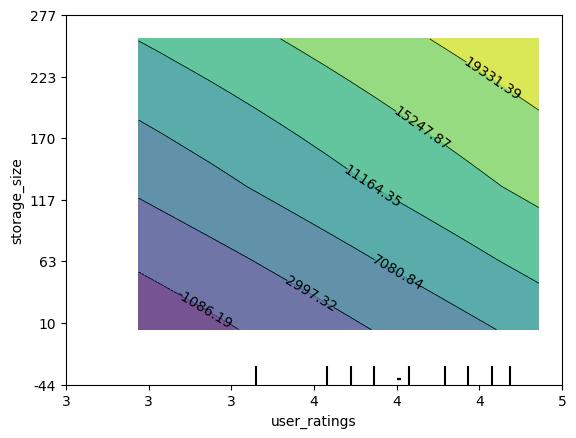

In [4]:
from sklearn.inspection import PartialDependenceDisplay

scaler = TRANSFORMER.named_transformers_["num"].named_steps["scaler"]

x_test_array = X_test.toarray()
ax = PartialDependenceDisplay.from_estimator(MODEL, x_test_array, [(0,2)], categorical_features=[7], feature_names=x_test.columns.tolist())


# Ticks user_ratings
ticks_user = ax.axes_[0, 0].get_xticks()
ticks_user_original = (
    ticks_user * scaler.scale_[0]
    + scaler.mean_[0]
)

ax.axes_[0, 0].set_xticks(ticks_user)
ax.axes_[0, 0].set_xticklabels(
    [f"{x:.0f}" for x in ticks_user_original]
)


# Ticks storage size
ticks_storage = ax.axes_[0, 0].get_yticks()
ticks_storage_original = (
    ticks_storage * scaler.scale_[2]
    + scaler.mean_[2]
)
ax.axes_[0, 0].set_yticks(ticks_storage)
ax.axes_[0, 0].set_yticklabels(
    [f"{x:.0f}" for x in ticks_storage_original]
)